This notebook is used to estimante the number of submission and/or accepted papers for each country. The paper and user data are extracted from CMT.
The data are approximaetd since the country information in CMT is only related to users, but it is a non-mandatory information.
The script seqauentially test all authors until a country information is present, otherwise the information is skipped.

Michele Scarpiniti -- DIET Dpt. (Sapienza University of Rome)

In [1]:
import pandas as pd
import IJCNN_utils as ut
import matplotlib.pyplot as plt

In [2]:
# Set file names
path = './data/'
dest = './report/'
users_file = path + 'Users.txt'
paper_file = path + 'All_Accepted_Papers.xlsx'

country_file = dest + 'Country_accepted-papers.xlsx'
org_file = dest + 'Organization_Accepted.xlsx'

In [3]:
# Load data
df = ut.load_users(users_file)
df.set_index('Email', inplace=True)
papers = ut.load_submissions(paper_file)

There are 18022 missing values
There are 421 missing values


There are 5698 missing data
There are 6600 valid data
Users come from 72 different countries


<Axes: xlabel='Country'>

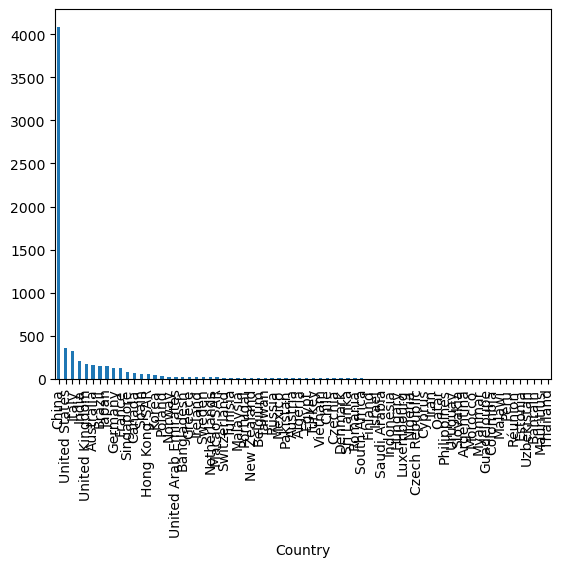

In [4]:
# Extract country information
country = df['Country']
print('There are {} missing data'.format(country.isnull().sum()))

country.dropna(inplace=True)
print('There are {} valid data'.format(len(country)))

country_names = list(set(country))
print('Users come from {} different countries'.format(len(country_names)))

country_count = country.value_counts()
plt.figure()
country_count.plot(kind='bar')

In [5]:
# Count papers for each country
paper_country = {el:0 for el in country_names}

pap_per_count = ut.count_country(df, papers, country_names, sort='value')

print('Total number of papers with country information:', pap_per_count.sum())

Total number of papers with country information: 1913


In [6]:
# Save to excel the paper per country
pap_per_count.to_excel(country_file)

In [7]:
# Print the top three contries
print('\n')
for i in range(3):
    print(pap_per_count.index[i], ':', round(100*pap_per_count.iloc[i]/pap_per_count.sum(),2))



China : 62.21
Italy : 7.74
United States : 4.86


Extract the main organization from each paper

In [8]:
# Extract the main organization from each paper
organizations = []
for i in range(len(papers)):
    o = ut.getMainOrganization(papers.iloc[i]['Authors'])
    organizations.append(o)

In [9]:
# Create the DataFram with organization information
org_df = pd.DataFrame(organizations)
org_df.columns = ['Organization']

org_df.to_excel(org_file)